In [5]:
import kagglehub

path = kagglehub.dataset_download("saurabhshahane/electricity-load-forecasting")

print(path)

Using Colab cache for faster access to the 'electricity-load-forecasting' dataset.
/kaggle/input/electricity-load-forecasting


In [6]:
import pandas as pd
import os

files = os.listdir(path)
print(files)

['train_dataframes.xlsx', 'continuous dataset.csv', 'test_dataframes.xlsx', 'weekly pre-dispatch forecast.csv']


In [7]:
df = pd.read_csv(os.path.join(path, "continuous dataset.csv"))
df.head()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48048 entries, 0 to 48047
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    48048 non-null  object 
 1   nat_demand  48048 non-null  float64
 2   T2M_toc     48048 non-null  float64
 3   QV2M_toc    48048 non-null  float64
 4   TQL_toc     48048 non-null  float64
 5   W2M_toc     48048 non-null  float64
 6   T2M_san     48048 non-null  float64
 7   QV2M_san    48048 non-null  float64
 8   TQL_san     48048 non-null  float64
 9   W2M_san     48048 non-null  float64
 10  T2M_dav     48048 non-null  float64
 11  QV2M_dav    48048 non-null  float64
 12  TQL_dav     48048 non-null  float64
 13  W2M_dav     48048 non-null  float64
 14  Holiday_ID  48048 non-null  int64  
 15  holiday     48048 non-null  int64  
 16  school      48048 non-null  int64  
dtypes: float64(13), int64(3), object(1)
memory usage: 6.2+ MB


In [9]:
df.describe()

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
count,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000
mean,1182.868647,27.399111,0.018313,0.079979,13.391049,26.921023,0.017844,0.106265,7.046675,24.719513,0.016867,0.144681,3.567589,0.704795,0.062937,0.727793
std,192.068896,1.675462,0.001607,0.065589,7.295502,3.018129,0.001889,0.086293,4.103711,2.414019,0.001584,0.087899,1.710522,3.147470,0.242852,0.445100
min,85.192500,22.953455,0.012054,0.000000,0.008979,19.765222,0.010247,0.000009,0.060394,19.933740,0.009655,0.000032,0.015497,0.000000,0.000000,0.000000
25%,1020.056900,26.160455,0.017236,0.026451,7.544958,24.769281,0.016584,0.036819,3.955051,22.954652,0.015800,0.075775,2.298887,0.000000,0.000000,0.000000
50%,1168.427700,27.118051,0.018590,0.065201,12.182103,26.167352,0.018351,0.085968,5.992762,24.001718,0.017167,0.130188,3.413994,0.000000,0.000000,1.000000
75%,1327.563950,28.558344,0.019521,0.117310,18.661282,28.712335,0.019242,0.157288,9.409871,26.243402,0.018067,0.200012,4.670628,0.000000,0.000000,1.000000
max,1754.882000,35.039575,0.022690,0.521240,39.229726,39.063440,0.022165,0.484985,24.483937,34.216211,0.021066,0.477783,10.288902,22.000000,1.000000,1.000000


In [10]:
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')
df.set_index('datetime', inplace=True)

df.head()

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
datetime,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [11]:
target = 'nat_demand'

In [12]:
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month

In [13]:
df['lag_1'] = df[target].shift(1)
df['lag_24'] = df[target].shift(24)

In [14]:
df['rolling_mean_24'] = df[target].rolling(window=24).mean()

In [15]:
df = df.dropna()

In [16]:
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

In [17]:
features = [col for col in df.columns if col != target]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

In [29]:
!pip install xgboost

In [30]:
from xgboost import XGBRegressor

In [31]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=50),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(n_estimators=50, verbosity=0)
}

In [32]:
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    results[name] = mae

    print(f"{name} MAE: {mae}")


Training Linear Regression...
Linear Regression MAE: 35.978708429841014

Training Random Forest...
Random Forest MAE: 19.27635420444604

Training Gradient Boosting...
Gradient Boosting MAE: 20.37933241816265

Training XGBoost...
XGBoost MAE: 19.49972651231455


In [33]:
print("\n=== Model Comparison ===")

for name, mae in results.items():
    print(f"{name}: {mae}")


=== Model Comparison ===
Linear Regression: 35.978708429841014
Random Forest: 19.27635420444604
Gradient Boosting: 20.37933241816265
XGBoost: 19.49972651231455


In [34]:
best_model = min(results, key=results.get)

print(f"\nBest Model: {best_model}")
print(f"Best MAE: {results[best_model]}")


Best Model: Random Forest
Best MAE: 19.27635420444604


In [35]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=50)
model.fit(X_train, y_train)

# ✅ ADD THIS HERE
import pickle
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(features, open("features.pkl", "wb"))

In [37]:
preds = model.predict(X_test)

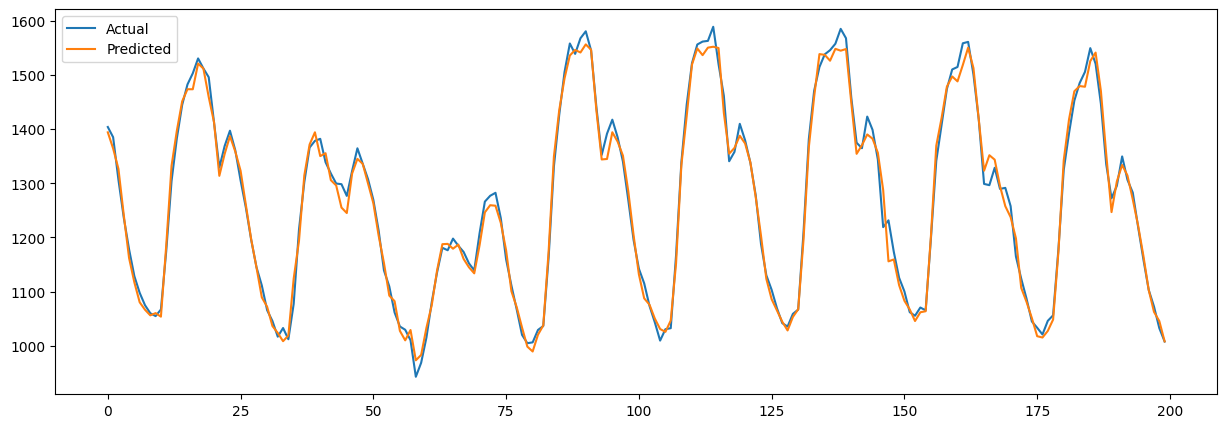

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(preds[:200], label="Predicted")
plt.legend()
plt.show()

In [41]:
import pickle

model = pickle.load(open("model.pkl", "rb"))
features = pickle.load(open("features.pkl", "rb"))

In [27]:
# take latest available data
last_row = df.iloc[-1:].copy()

# auto-calculate lag values
lag_1 = df['nat_demand'].iloc[-1]
lag_24 = df['nat_demand'].iloc[-24]

# ask only simple things
hour = int(input("Enter hour you want to predict (0-23): "))
day = int(input("Enter day of week (0=Mon, 6=Sun): "))
month = int(input("Enter month (1-12): "))

# update values
last_row['hour'] = hour
last_row['day_of_week'] = day
last_row['month'] = month

last_row['lag_1'] = lag_1
last_row['lag_24'] = lag_24
last_row['rolling_mean_24'] = df['nat_demand'].tail(24).mean()

# predict
input_data = last_row[features]
prediction = model.predict(input_data)[0]

print(f"\nPredicted electricity demand for the given time is: {prediction:.2f} MW")

Enter hour you want to predict (0-23): 5
Enter day of week (0=Mon, 6=Sun): 0
Enter month (1-12): 2

Predicted electricity demand for the given time is: 1024.40 MW
